In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from knnbench.functions_to_use import run_manual_grid_adult, run_manual_one_adult, run_sklearn_grid_adult, compare_manual_vs_sklearn_adult

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
os.makedirs("results", exist_ok=True)

Below are examples of how to use each of the 4 fuction in "functions_to_use.py", above are the imports (run that first).
I added how long it took to run things for me for reference.

Function: run_manual_grid_adult
-took 8m 19.1s to run with [3, 5, 7, 9, 11, 20]
-took 1m 12.8s with [20]

In [2]:
k = [20]
scalings = [None, "standard", "minmax"]
votings = ["uniform", "distance"]
tie_breaks = ["nearest", "min_class"]

manual_rows = run_manual_grid_adult(
    ks=k,
    scalings=scalings,
    votings=votings,
    tie_breaks=tie_breaks,
    seed=42,
    batch_size=512,
    include_ties=True,
)

df_manual = pd.DataFrame(manual_rows).sort_values(
    ["k", "scaling", "weights", "tie_break"]
).reset_index(drop=True)

df_manual

,model,k,scaling,weights,tie_break,accuracy,macro_recall,macro_f1,ties
0,manual,20,minmax,distance,min_class,0.831917,0.742212,0.755518,1
1,manual,20,minmax,distance,nearest,0.831917,0.742212,0.755518,1
2,manual,20,minmax,uniform,min_class,0.836933,0.737301,0.756182,248
3,manual,20,minmax,uniform,nearest,0.838776,0.748186,0.763636,248
4,manual,20,standard,distance,min_class,0.840721,0.758845,0.770676,1
5,manual,20,standard,distance,nearest,0.840618,0.758777,0.770566,1
6,manual,20,standard,uniform,min_class,0.847784,0.754693,0.773757,276
7,manual,20,standard,uniform,nearest,0.846863,0.765960,0.778869,276
8,manual,20,NaN,distance,min_class,0.857508,0.778820,0.793427,15
9,manual,20,NaN,distance,nearest,0.857201,0.779058,0.793289,15


Function: run_manual_one_adult
-took 7.2s to run

Config: {'model': 'manual', 'k': 20, 'scaling': 'standard', 'voting': 'uniform', 'tie_break': 'nearest', 'seed': 42, 'batch_size': 512}
Ties: 276

accuracy: 0.8469
macro_recall: 0.7660
macro_f1: 0.7789
precision_<=50K: 0.8827
recall_<=50K: 0.9211
f1_<=50K: 0.9015
precision_>50K: 0.7090
recall_>50K: 0.6108
f1_>50K: 0.6562


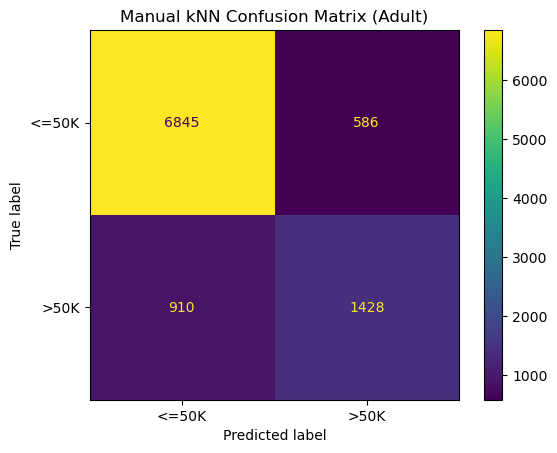

In [8]:
k = 20
scalings = "standard"
votings = "uniform"
tie_breaks = "nearest"

out_manual = run_manual_one_adult(
    k=k,
    scaling=scalings,
    voting=str(votings),
    tie_break=str(tie_breaks),
)

print("Config:", out_manual["config"])
print("Ties:", out_manual["ties"])
print()

for k, v in out_manual["metrics"].items():
    print(f"{k}: {v:.4f}")

cm = out_manual["confusion_matrix"]
labels = out_manual["labels"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")

plt.title("Manual kNN Confusion Matrix (Adult)")
plt.show()

Function: run_sklearn_grid_adult
-took 11.3s to run for k=[20]

In [12]:
k = [20]
scalings = [None, "standard", "minmax"]

sk_rows = run_sklearn_grid_adult(
    ks=k,
    scalings=scalings,
    weights_list=["uniform", "distance"],
    seed=42,
)

df_sklearn = pd.DataFrame(sk_rows).sort_values(
    ["k", "scaling", "weights"]
).reset_index(drop=True)

df_sklearn

,model,k,scaling,weights,tie_break,accuracy,macro_recall,macro_f1
0,sklearn,20,minmax,distance,None,0.829768,0.736255,0.750683
1,sklearn,20,minmax,uniform,None,0.837650,0.737479,0.756782
2,sklearn,20,standard,distance,None,0.838571,0.753474,0.766321
3,sklearn,20,standard,uniform,None,0.847784,0.755866,0.774385
4,sklearn,20,NaN,distance,None,0.855768,0.775625,0.790523
5,sklearn,20,NaN,uniform,None,0.859863,0.768789,0.790467


Function: compare_manual_vs_sklearn_adult
-took 49.1s to run for k=[20]

In [13]:
k = [20]
scalings = [None, "standard", "minmax"]

cmp_rows = compare_manual_vs_sklearn_adult(
    ks=k,
    scalings=scalings,
    weights_list=["uniform", "distance"],
    seed=42,
    batch_size=512,
)

df_cmp = pd.DataFrame(cmp_rows).sort_values(
    ["k", "scaling", "weights"]
).reset_index(drop=True)

df_cmp

,k,scaling,weights,accuracy_manual,accuracy_sklearn,d_accuracy,macro_recall_manual,macro_recall_sklearn,d_macro_recall,macro_f1_manual,macro_f1_sklearn,d_macro_f1
0,20,minmax,distance,0.831917,0.829768,0.002150,0.742212,0.736255,0.005957,0.755518,0.750683,0.004835
1,20,minmax,uniform,0.836933,0.837650,-0.000717,0.737301,0.737479,-0.000178,0.756182,0.756782,-0.000600
2,20,standard,distance,0.840721,0.838571,0.002150,0.758845,0.753474,0.005370,0.770676,0.766321,0.004355
3,20,standard,uniform,0.847784,0.847784,0.000000,0.754693,0.755866,-0.001173,0.773757,0.774385,-0.000627
4,20,NaN,distance,0.857508,0.855768,0.001740,0.778820,0.775625,0.003196,0.793427,0.790523,0.002904
5,20,NaN,uniform,0.861705,0.859863,0.001843,0.771319,0.768789,0.002530,0.793222,0.790467,0.002755
